In [ ]:
# Evaluates a Chebyshev expansion at a given
# x value using the Clenshaw algorithm.
def chebyshev_eval(coeffs, x, x_min, x_max):
    x_rel_2 = -2 + 4 * (x - x_min) / float(x_max - x_min)
    d = 0
    dd = 0
    temp = 0
    for ci in coeffs[-1:0:-1]:
        temp = d
        d = x_rel_2 * d - dd + ci
        dd = temp
    return 0.5 * x_rel_2 * d - dd + 0.5 * coeffs[0]

# 8 term expansion coefficients for
# f(x)=1/(1+Math.exp(-x))
# x_min=-5, x_max=5
coeffs = [
    0.5,
    0.5877456547980334,
    -5.789639601072594e-17,
    -0.12179174010117828,
    -4.119968255444917e-18,
    0.036311064010458874,
    -1.7694179454963432e-16,
    -0.013954006211276076
]
x_min = -5
x_max = 5

# Evaluate the approximation at the interval midpoint
x_mid = 0.5 * (x_min + x_max)
value_at_x_mid = chebyshev_eval(coeffs, x_mid, x_min, x_max)
print("Value at", x_mid , "is", str(value_at_x_mid))
print("Should be", 0.5000000000000002, "(double precision)");

Value at 0.0 is 0.2500000000000002
Should be 0.5000000000000002 (double precision)


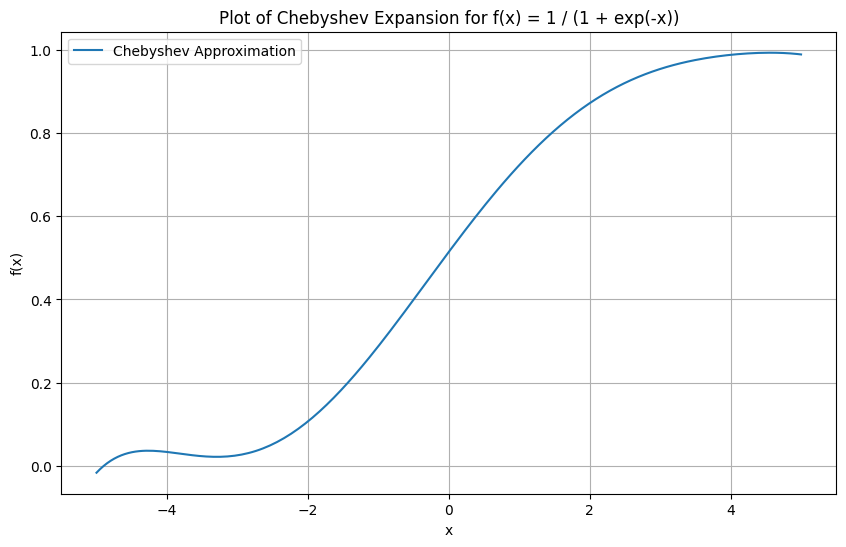

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Re-using the chebyshev_eval function and coefficients from the previous cell
# Evaluates a Chebyshev expansion at a given
# x value using the Clenshaw algorithm.
def chebyshev_eval(coeffs, x, x_min, x_max):
    x_rel_2 = -2 + 4 * (x - x_min) / float(x_max - x_min)
    d = 0
    dd = 0
    temp = 0
    for ci in coeffs[-1:0:-1]:
        temp = d
        d = x_rel_2 * d - dd + ci
        dd = temp
    return 0.5 * x_rel_2 * d - dd + 0.5 * coeffs[0]

# 8 term expansion coefficients for
# f(x)=1/(1+Math.exp(-x))
# x_min=-5, x_max=5
coeffs = [
    1,
    0.5877456547980334,
    -5.789639601072594e-17,
    -0.12179174010117828,
    -4.119968255444917e-18,
    0.036311064010458874
    -1.7694179454963432e-16,
    -0.013954006211276076
]
x_min = -5
x_max = 5

# Generate x values for the plot
x_values = np.linspace(x_min, x_max, 200)

# Evaluate the function for each x value
y_values = [chebyshev_eval(coeffs, x, x_min, x_max) for x in x_values]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='Chebyshev Approximation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of Chebyshev Expansion for f(x) = 1 / (1 + exp(-x))')
plt.grid(True)
plt.legend()
plt.show()

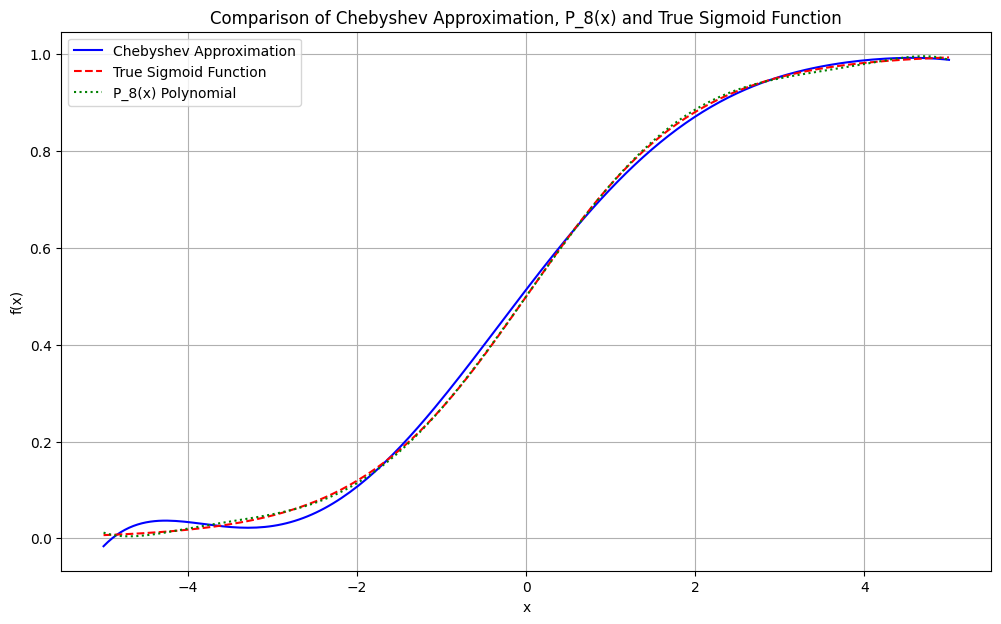

In [ ]:
import math

# Define the true sigmoid function
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# Define the P_8(x) polynomial function
def P_8(x):
    return 0.5 + 0.24652*x - 0.0159776*x**3 + 0.000687616*x**5 - 0.0000114688*x**7

# Evaluate the true sigmoid function for the same x values
y_sigmoid_values = [sigmoid(x) for x in x_values]

# Evaluate the P_8(x) polynomial for the same x values
y_p8_values = [P_8(x) for x in x_values]

# Create the plot comparing all three functions
plt.figure(figsize=(12, 7))
plt.plot(x_values, y_values, label='Chebyshev Approximation', color='blue')
plt.plot(x_values, y_sigmoid_values, label='True Sigmoid Function', linestyle='--', color='red')
plt.plot(x_values, y_p8_values, label='P_8(x) Polynomial', linestyle=':', color='green')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Comparison of Chebyshev Approximation, P_8(x) and True Sigmoid Function')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def get_chebyshev_nodes(n, x_min, x_max):
    # Chebyshev nodes in [-1, 1]
    k = np.arange(1, n + 1)
    nodes_std = np.cos((2 * k - 1) * np.pi / (2 * n))
    # Map to [x_min, x_max]
    return 0.5 * (x_max + x_min) + 0.5 * (x_max - x_min) * nodes_std

def update_plot(n=8):
    x_min, x_max = -5, 5
    nodes = get_chebyshev_nodes(n, x_min, x_max)
    y_nodes = sigmoid(nodes)

    # Fit Chebyshev polynomial
    poly = np.polynomial.Chebyshev.fit(nodes, y_nodes, deg=n-1, domain=[x_min, x_max])
    coeffs = poly.coef

    # Evaluation points
    x_range = np.linspace(x_min, x_max, 1000)
    y_true = sigmoid(x_range)
    y_approx = poly(x_range)
    error = y_true - y_approx

    # Calculate error stats
    max_err = np.max(error)
    min_err = np.min(error)
    # Total error area (Integral of absolute error)
    error_area = np.trapz(np.abs(error), x_range)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1]})

    # Top plot: Approximation
    ax1.plot(x_range, y_true, 'r--', label='True Sigmoid', alpha=0.7)
    ax1.plot(x_range, y_approx, 'b-', label=f'Chebyshev Approx (N={n})')
    ax1.scatter(nodes, y_nodes, color='black', zorder=5, label='Chebyshev Nodes')
    ax1.set_title(f'Chebyshev Interpolation of Sigmoid (Nodes: {n})')
    ax1.legend()
    ax1.grid(True)

    # Bottom plot: Error
    ax2.plot(x_range, error, 'g-', label='Error (True - Approx)')
    ax2.axhline(0, color='black', lw=1)
    ax2.set_ylabel('Residual Error')
    ax2.set_xlabel('x')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"--- Error Statistics ---")
    print(f"Max Error: {max_err:.6e}")
    print(f"Min Error: {min_err:.6e}")
    print(f"Total Error Area: {error_area:.6e}")
    print(f"\n--- Node Locations and Coefficients (N={n}) ---")
    for i in range(n):
        print(f"Node {i+1}: x = {nodes[i]:.4f} | Coeff T_{i}(x) = {coeffs[i]:.6e}")

interact(update_plot, n=IntSlider(min=2, max=30, step=1, value=8));

interactive(children=(IntSlider(value=8, description='n', max=30, min=2), Output()), _dom_classes=('widget-int…

The plot above shows the Chebyshev approximation compared to the true sigmoid function. This visualization helps in understanding how closely the polynomial approximation matches the actual function over the given interval.

In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline

# Data points provided
x = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
y = np.array([0.0067, 0.0180, 0.0474, 0.1192, 0.2689, 0.5000, 0.7311, 0.8808, 0.9526, 0.9820, 0.9933])

# Calculate 3rd order spline (Cubic Spline)
cs = CubicSpline(x, y, bc_type='not-a-knot')

print("MATHEMATICAL DEFINITION:")
print("A cubic spline S(x) is a piecewise polynomial defined on the interval [x_0, x_n].")
print("For each sub-interval [x_i, x_{i+1}], the spline is defined by a cubic polynomial S_i(x):")
print("S_i(x) = a_i(x - x_i)^3 + b_i(x - x_i)^2 + c_i(x - x_i) + d_i")
print("\nConstraints:")
print("1. S(x_i) = y_i (Interpolation)")
print("2. S_i(x_{i+1}) = S_{i+1}(x_{i+1}) (Continuity)")
print("3. S'_i(x_{i+1}) = S'_{i+1}(x_{i+1}) (First derivative continuity)")
print("4. S''_i(x_{i+1}) = S''_{i+1}(x_{i+1}) (Second derivative continuity)")
print("-" * 60)

print("Cubic Spline Coefficients (a_i, b_i, c_i, d_i):")
# cs.c contains coefficients in order: [a, b, c, d]
for i in range(len(x) - 1):
    coeffs = cs.c[:, i]
    print(f"Segment {i} ([{x[i]}, {x[i+1]}]):")
    print(f"  a: {coeffs[0]:.6f}, b: {coeffs[1]:.6f}, c: {coeffs[2]:.6f}, d: {coeffs[3]:.6f}")

MATHEMATICAL DEFINITION:
A cubic spline S(x) is a piecewise polynomial defined on the interval [x_0, x_n].
For each sub-interval [x_i, x_{i+1}], the spline is defined by a cubic polynomial S_i(x):
S_i(x) = a_i(x - x_i)^3 + b_i(x - x_i)^2 + c_i(x - x_i) + d_i

Constraints:
1. S(x_i) = y_i (Interpolation)
2. S_i(x_{i+1}) = S_{i+1}(x_{i+1}) (Continuity)
3. S'_i(x_{i+1}) = S'_{i+1}(x_{i+1}) (First derivative continuity)
4. S''_i(x_{i+1}) = S''_{i+1}(x_{i+1}) (Second derivative continuity)
------------------------------------------------------------
Cubic Spline Coefficients (a_i, b_i, c_i, d_i):
Segment 0 ([-5, -4]):
  a: 0.003422, b: -0.001215, c: 0.009093, d: 0.006700
Segment 1 ([-4, -3]):
  a: 0.003422, b: 0.009050, c: 0.016928, d: 0.018000
Segment 2 ([-3, -2]):
  a: 0.007191, b: 0.019315, c: 0.045293, d: 0.047400
Segment 3 ([-2, -1]):
  a: 0.003313, b: 0.040889, c: 0.105498, d: 0.119200
Segment 4 ([-1, 0]):
  a: -0.016943, b: 0.050828, c: 0.197215, d: 0.268900
Segment 5 ([0, 1]):
  a: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def create_spline_manual(xs, ys):
    """Implementation of the spline algorithm provided in the user context."""
    n = len(xs)
    a = ys.copy()
    h = np.zeros(n - 1)
    for i in range(n - 1):
        h[i] = xs[i + 1] - xs[i]

    alpha = np.zeros(n - 1)
    for i in range(1, n - 1):
        alpha[i] = (3 / h[i]) * (a[i + 1] - a[i]) - (3 / h[i - 1]) * (a[i] - a[i - 1])

    c = np.zeros(n)
    l = np.zeros(n)
    mu = np.zeros(n)
    z = np.zeros(n)

    l[0] = 1
    for i in range(1, n - 1):
        l[i] = 2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * mu[i - 1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i - 1] * z[i - 1]) / l[i]

    l[n - 1] = 1
    # c[n-1] is 0 (natural boundary/z[n-1] logic)

    b = np.zeros(n - 1)
    d = np.zeros(n - 1)

    for j in range(n - 2, -1, -1):
        c[j] = z[j] - mu[j] * c[j + 1]
        b[j] = (a[j + 1] - a[j]) / h[j] - (h[j] * (c[j + 1] + 2 * c[j])) / 3
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])

    def evaluate(x):
        # Vectorized evaluation
        x = np.atleast_1d(x)
        results = np.zeros_like(x)
        for idx, val in enumerate(x):
            i = n - 2
            for j in range(n - 1):
                if val >= xs[j] and val <= xs[j + 1]:
                    i = j
                    break
            dx = val - xs[i]
            results[idx] = a[i] + b[i] * dx + c[i] * (dx ** 2) + d[i] * (dx ** 3)
        return results

    return evaluate, (a, b, c, d)

def update_spline_viewer(node_count=6):
    x_min, x_max = -5, 5
    xs = np.linspace(x_min, x_max, node_count)
    ys = sigmoid(xs)

    spline_func, coeffs = create_spline_manual(xs, ys)
    a, b, c, d = coeffs

    x_range = np.linspace(x_min, x_max, 1000)
    y_true = sigmoid(x_range)
    y_approx = spline_func(x_range)
    error = y_true - y_approx

    # Stats
    max_err = np.max(np.abs(error))
    min_err = np.min(error)
    total_area = np.trapz(np.abs(error), x_range)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(x_range, y_true, 'r--', label='Sigmoid', alpha=0.6)
    ax1.plot(x_range, y_approx, 'b-', label='Spline Interpolation')
    ax1.scatter(xs, ys, color='black', label='Nodes')
    ax1.set_title(f'Spline Interpolation (Nodes: {node_count})')
    ax1.legend()
    ax1.grid(True)

    ax2.fill_between(x_range, error, color='red', alpha=0.2)
    ax2.plot(x_range, error, 'r-', label='Residual Error')
    ax2.axhline(0, color='black', lw=1)
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"--- Error Statistics ---")
    print(f"Max Absolute Error: {max_err:.6e}")
    print(f"Min Error: {min_err:.6e}")
    print(f"Total Error Area: {total_area:.6e}")
    print(f"\n--- Node Locations ---\n{xs}")
    print(f"\n--- Coefficients (Segment i: a + b*dx + c*dx^2 + d*dx^3) ---")
    for i in range(node_count - 1):
        print(f"Segment {i} [{xs[i]:.2f} to {xs[i+1]:.2f}]: a={a[i]:.4e}, b={b[i]:.4e}, c={c[i]:.4e}, d={d[i]:.4e}")

interact(update_spline_viewer, node_count=IntSlider(min=3, max=25, step=1, value=6));

interactive(children=(IntSlider(value=6, description='node_count', max=25, min=3), Output()), _dom_classes=('w…

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def true_sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- Approximation Functions ---


def s2_x(x):
    # MAC Estimation: ~6 MACs per cubic branch
    if x < -5: return 0.0
    if x > 5: return 1.0
    if -5 <= x < -5/3: return (477*x**3 + 7155*x**2 + 35039*x + 56614)/100000
    if -5/3 <= x < 5/3: return (-954*x**3 + 23120*x + 50000)/100000
    if 5/3 <= x <= 5: return (477*x**3 - 7161*x**2 + 35093*x + 43256)/100000
    return 1.0

def f_x(x):
    # 7th degree polynomial. Horner's: 7 MACs.
    if x < -2: return 0.0
    if x > 2: return 1.0
    return 0.5 + 0.25*x - (1/48)*x**3 + (1/480)*x**5 - (17/80640)*x**7

def f2_x(x):
    # 7th degree: 7 MACs.
    if x < -5: return 0.0
    if x > 5: return 1.0
    return 0.5 + (6163/25000)*x - (4993/312500)*x**3 + (1343/1953125)*x**5 - (112/9765625)*x**7

def f3_x(x):
    # 5th degree: 5 MACs.
    if x < -5: return 0.0
    if x > 5: return 1.0
    return (23539/100000000)*x**5 - (283629/25000000)*x**3 + (2980581/12500000)*x + 0.5

def f4_x(x):
    # 5th degree + clamp: 5 MACs + 2 comparisons.
    val = 0.5 + (6163/25000)*x - (4993/312500)*x**3 + (1343/1953125)*x**5
    return min(max(val, 0), 1)

def f5_x(x):
    # 5th degree denom + 1 div: 5 MACs + 1 Div.
    if x > 2.5: return 1.0
    denom = 2 - x + (x**2)/2 - (x**3)/6 + (x**4)/24 - (x**5)/120
    if denom == 0: return 0.0
    return max(min(1/denom, 1), 0)

def f6_x(x):
    # Rational: Degree 3 / Degree 2. ~3 MACs (top) + 2 MACs (bottom) + 1 Div.
    val = (120 + 60*x + 12*x**2 + x**3) / (240 + 24*x**2)
    return min(max(val, 0), 1)

functions_map = {
    'S2(x)': (s2_x, "~6 (Piecewise Cubic)"),
    'f(x)': (f_x, "7 (7th Degree Poly)"),
    'f2(x)': (f2_x, "7 (7th Degree Poly)"),
    'f3(x)': (f3_x, "5 (5th Degree Poly)"),
    'f4(x)': (f4_x, "5 (5th Degree Poly) + Clamping"),
    'f5(x)': (f5_x, "5 (5th Degree Poly) + 1 Division"),
    'f6(x)': (f6_x, "~5 (Rational Function) + 1 Division")
}

def compare_sigmoid(func_name):
    x_range = np.linspace(-6, 6, 1000)
    y_true = true_sigmoid(x_range)

    target_func, mac_est = functions_map[func_name]
    y_approx = np.array([target_func(xi) for xi in x_range])
    error = y_true - y_approx

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2, 1]})

    ax1.plot(x_range, y_true, 'r--', label='True Sigmoid', alpha=0.7)
    ax1.plot(x_range, y_approx, 'b-', label=f'Approximation: {func_name}')
    ax1.set_title(f'Comparison: Sigmoid vs {func_name}')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(x_range, error, 'g-', label='Error (True - Approx)')
    ax2.fill_between(x_range, error, color='green', alpha=0.1)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_ylabel('Residual Error')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    max_err = np.max(error)
    min_err = np.min(error)
    abs_max_err = np.max(np.abs(error))
    error_area = np.trapz(np.abs(error), x_range)

    print(f"--- Statistics for {func_name} ---")
    print(f"Estimated MAC Ops per point: {mac_est}")
    print(f"Max Error: {max_err:.6e}")
    print(f"Min Error: {min_err:.6e}")
    print(f"Max Absolute Error: {abs_max_err:.6e}")
    print(f"Total Error Area (L1): {error_area:.6e}")

interact(compare_sigmoid, func_name=list(functions_map.keys()));

interactive(children=(Dropdown(description='func_name', options=('S2(x)', 'f(x)', 'f2(x)', 'f3(x)', 'f4(x)', '…